In [ ]:
# ---- importing functions ----
import sys
import numpy as np
import matplotlib.pyplot as plt

# importing slow dynamics pipeline
pipeline_dir = 'C:/Users/ys2605/Desktop/stuff/slow_dynamics_analysis'    # edit this  
sys.path.append(pipeline_dir + '/functions')
import sd_utils as sd
import sd_decoder as dec

seed = 0           # integer for reproducible results, or None for random

In [ ]:
# ---- loading RNN testing with control datasets ----
# input is the spectrogram inputs
# target is the index when oddball trial happens
# rates (time, run, neurons)
# returns a list of dicts (one per network); firing_rates is (neurons, time) if flatten_runs else (runs, neurons, time)

data_dir = 'F:/RNN_stuff/RNN_data/test_data/'
fname = 'RNN_test_data_2024_5_24_9h_42m2'
data_rnn = sd.load_rnn_test(
    data_dir, 
    fname + '_cont_data.npy',
    fname + '_params.npy',
    max_net_load = 2,               # max networks per type (lower = less memory)
    flatten_runs = True,            # False: 3D (runs, neurons, time); True: 2D (neurons, time)
    max_trial_types = 10,           # keep first N stimulus types (flattened only)
    max_trials = 400,               # keep first N trials (flattened only)
    limit_network_types=['ob trained', 'freq trained'],     # types to load; [] = all
    seed=seed)                      # reproducibility seed (None = random)

frame_rate = 1000/np.mean(sd.get_values(data_rnn, 'volume_period')) # in Hz; edit this for external datasets
training_type = np.array(sd.get_values(data_rnn, 'training'))

Text(0.5, 0, 'Frames')

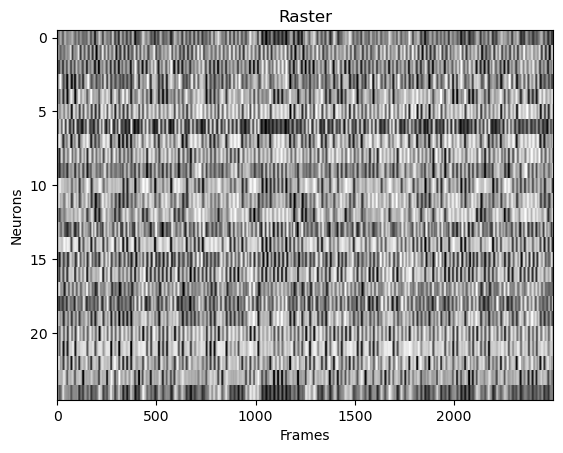

In [4]:
fig = plt.figure()
plt.imshow(sd.normalize(data_rnn[0]['firing_rates'][:,2000:4500]), aspect='auto', cmap='gist_yarg', interpolation='none')
plt.title('Raster')
plt.ylabel('Neurons')
plt.xlabel('Frames')

In [5]:
# compute trial window frames (assuming all datasets have similar frame rate)
trial_frames, plot_t = sd.get_frames(
    trial_win=[-1,3],         # sec relative to stim onset (pre, post)
    frame_rate=frame_rate)

# computing stimulus triggered average (neurons, frames, trials)
stim_trig_resp_all = []
for n_fl in range(len(data_rnn)):  
    stim_trig_resp = sd.get_stim_trig_resp(
        data_rnn[n_fl]['firing_rates'],    # firing rates
        data_rnn[n_fl]['stim_times'],      # stimulus onset frames
        trial_frames=trial_frames)        # frames to be extracted
    
    stim_trig_resp_all.append(stim_trig_resp)

In [ ]:
def f_diag_decoder(stim_trig_resp, trial_types, seed=None):
    # the same responses are passed twice in X_all; the control is the label-shuffled
    # version in Y_all (trial labels shuffled), not a second, different dataset
    X_all = [stim_trig_resp,
             stim_trig_resp]

    Y_all = [trial_types,
             dec.shuffle_trials(trial_types, seed=seed)]   # label-shuffled control
    
    dec_data = dec.run_binwise_dec(
        X_all,
        Y_all,
        train_test_method='diag',   # options: full, diag, train_at_stim, test_at_stim
        pca_var_frac=1,             # reduce data with pca
        num_cv=5,                   # cross validation
        normalize=False,
        add_noise_sigma=1e-5,       # for stability 
        get_train_coeffs=True, seed=seed)

    return dec_data

In [ ]:
# run for all datasets
dec_data_all = []
for n_fl in range(len(data_rnn)):
    print('Training dataset %d/%d' % (n_fl+1, len(stim_trig_resp_all)))

    dec_data = f_diag_decoder(
        stim_trig_resp_all[n_fl],
        data_rnn[n_fl]['trial_types'], seed=seed)

    dec_data_all.append(dec_data)
    
print('Done')   

Training dataset 1/5


In [ ]:
figs_diag = dec.plot_binwise_dec(dec_data_all,
                               plot_t=plot_t,
                               plot_legend=('Data', 'Shuff'),
                               plot_start=-1,
                               plot_end=3,
                               title_tag='Freq single trial decoder')